<a href="https://colab.research.google.com/github/FeLocci/senacai/blob/main/MFCC_analise_de_som_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\#**Inicio do código**

\#Download do dataset

In [ ]:
import kagglehub
import os
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from sklearn.model_selection import train_test_split
import os
import pandas as pd # Import pandas for reading metadata
import random

# 1. DOWNLOAD
path = kagglehub.dataset_download("soumendraprasad/musical-instruments-sound-dataset")
# The actual audio files for training are in a subfolder structure, typically:
# <download_path>/Train_submission/Train_submission/
# The metadata (labels) are in:
# <download_path>/Train_submission/Metadata_Train.csv

# Print path information for debugging
print("Dataset downloaded to:", path)
print("Content of download directory:", os.listdir(path))
print("Content of Train_submission directory:", os.listdir(os.path.join(path, "Train_submission/Train_submission")))
print(os.listdir(os.path.join(path, "Train_submission")))


Using Colab cache for faster access to the 'musical-instruments-sound-dataset' dataset.
Dataset downloaded to: /kaggle/input/musical-instruments-sound-dataset
Content of download directory: ['Test_submission', 'Train_submission', 'Metadata_Train.csv', 'Metadata_Test.csv']
Content of Train_submission directory: ['the-last-piano-112677.wav', '2-E1-Minor 08.wav', '1_john-garner_bwv1002_mov4.wav', 'ROOM_room4_MUS_joplin_DEV_stereomic.wav', 'WaveDrum02_39KD (66).wav', 'WaveDrum02_39KD (9).wav', 'jinglepiano-105261.wav', 'alien-beeper-103420.wav', 'Vn-ord-F6-mf-1c.wav', 'Violin_Sound (298).wav', 'ROOM_room4_MUS_bartok_DEV_iphone.wav', '14_emil-telmanyi_bwv1003.wav', 'VIOLIN_SOUND (118).wav', 'ROOM_room3_MUS_swing_DEV_amazon.wav', 'WaveDrum02_43HH (50).wav', '1_ray-chen_bwv1004_mov5.wav', 'ROOM_room1_MUS_swing_DEV_iphone.wav', 'DRUM_SOUND (57).wav', 'ROOM_room1_MUS_swing_DEV_redmi.wav', 'VIOLIN_sound (72).wav', 'Violin_Sound (290).wav', 'LP_Lick3_KSBDN.wav', 'slow_rock_4_110BPM.wav', 'WaveDru

\# Funcão para transformar o som em um espectograma

\# Modificar a variável duration para a duração do áudio usado

Modificado para usar MFCCs e Melspectrogramas combinados.

In [ ]:
def audio_to_mfcc(audio_path, class_label):
    # Carrega 10 segundos
    y, sr = librosa.load(audio_path, duration=10)

    if len(y) == 0 or np.all(y == 0):
        return tf.zeros(IMG_SIZE + (3,), dtype=tf.float32)

    # Normalize the audio signal
    y = librosa.util.normalize(y)

    if class_label in ['Sound_Violin', 'Sound_Drum']:
        # Apply HPSS for specific classes
        D = librosa.stft(y)
        D_harmonic, D_percussive = librosa.decompose.hpss(D)

        mel_harmonic = librosa.feature.melspectrogram(S=np.abs(D_harmonic), sr=sr, n_mels=92)
        S_dB_harmonic = librosa.power_to_db(mel_harmonic + 1e-8, ref=np.max, top_db=80.0)

        mel_percussive = librosa.feature.melspectrogram(S=np.abs(D_percussive), sr=sr, n_mels=92)
        S_dB_percussive = librosa.power_to_db(mel_percussive + 1e-8, ref=np.max, top_db=80.0)

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # Add Zero-Crossing Rate (ZCR) and Chroma Features for these classes
        zcr = librosa.feature.zero_crossing_rate(y=y)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        # Normalize features
        min_val_h = np.min(S_dB_harmonic)
        max_val_h = np.max(S_dB_harmonic)
        normalized_harmonic = (S_dB_harmonic - min_val_h) / (max_val_h - min_val_h) if max_val_h != min_val_h else np.zeros_like(S_dB_harmonic)

        min_val_p = np.min(S_dB_percussive)
        max_val_p = np.max(S_dB_percussive)
        normalized_percussive = (S_dB_percussive - min_val_p) / (max_val_p - min_val_p) if max_val_p != min_val_p else np.zeros_like(S_dB_percussive)

        min_val_mfcc = np.min(mfccs)
        max_val_mfcc = np.max(mfccs)
        normalized_mfcc = (mfccs - min_val_mfcc) / (max_val_mfcc - min_val_mfcc) if max_val_mfcc != min_val_mfcc else np.zeros_like(mfccs)

        min_val_zcr = np.min(zcr)
        max_val_zcr = np.max(zcr)
        normalized_zcr = (zcr - min_val_zcr) / (max_val_zcr - min_val_zcr) if max_val_zcr != min_val_zcr else np.zeros_like(zcr)

        min_val_chroma = np.min(chroma)
        max_val_chroma = np.max(chroma)
        normalized_chroma = (chroma - min_val_chroma) / (max_val_chroma - min_val_chroma) if max_val_chroma != min_val_chroma else np.zeros_like(chroma)

        # Ensure all features have the same number of frames before concatenation
        min_len_frames = min(normalized_harmonic.shape[1], normalized_percussive.shape[1],
                             normalized_mfcc.shape[1], normalized_zcr.shape[1], normalized_chroma.shape[1])
        normalized_harmonic = normalized_harmonic[:, :min_len_frames]
        normalized_percussive = normalized_percussive[:, :min_len_frames]
        normalized_mfcc = normalized_mfcc[:, :min_len_frames]
        normalized_zcr = normalized_zcr[:, :min_len_frames]
        normalized_chroma = normalized_chroma[:, :min_len_frames]

        # Concatenate all features vertically
        combined_feature = np.concatenate((
            normalized_harmonic,
            normalized_percussive,
            normalized_mfcc,
            normalized_zcr,
            normalized_chroma
        ), axis=0)

    else:
        # For other classes, revert to Mel-spectrogram + MFCC without HPSS
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=184)
        S_dB = librosa.power_to_db(mel_spectrogram + 1e-8, ref=np.max, top_db=80.0)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        min_val_mel = np.min(S_dB)
        max_val_mel = np.max(S_dB)
        normalized_mel = (S_dB - min_val_mel) / (max_val_mel - min_val_mel) if max_val_mel != min_val_mel else np.zeros_like(S_dB)

        min_val_mfcc = np.min(mfccs)
        max_val_mfcc = np.max(mfccs)
        normalized_mfcc = (mfccs - min_val_mfcc) / (max_val_mfcc - min_val_mfcc) if max_val_mfcc != min_val_mfcc else np.zeros_like(mfccs)

        min_len_frames = min(normalized_mel.shape[1], normalized_mfcc.shape[1])
        normalized_mel = normalized_mel[:, :min_len_frames]
        normalized_mfcc = normalized_mfcc[:, :min_len_frames]

        combined_feature = np.concatenate((normalized_mel, normalized_mfcc), axis=0)

    img = tf.image.resize(np.expand_dims(combined_feature, -1), IMG_SIZE)
    img = tf.image.grayscale_to_rgb(img)
    return img

\# Função de aumento


In [ ]:
# --- Data Augmentation Function ---
def augment_spectrogram_image(spec_image, max_noise_std=0.05, time_warp_range=0.2, freq_mask_param=5, apply_masking_prob=0.5):
    # Convert to TensorFlow tensor if not already
    if not tf.is_tensor(spec_image):
        spec_image = tf.convert_to_tensor(spec_image, dtype=tf.float32)

    # 1. Add Gaussian noise
    noise = tf.random.normal(shape=tf.shape(spec_image), mean=0.0, stddev=tf.random.uniform([], 0, max_noise_std), dtype=tf.float32)
    augmented_image = spec_image + noise

    # 2. Apply Time Warping (temporal stretching/compression)
    time_warp_factor = tf.random.uniform([], 1 - time_warp_range, 1 + time_warp_range)
    original_width = tf.shape(augmented_image)[1] # Time axis is width

    warped_width = tf.cast(tf.cast(original_width, tf.float32) * time_warp_factor, tf.int32)

    warped_image = tf.image.resize(
        augmented_image,
        size=[tf.shape(augmented_image)[0], warped_width],
        method=tf.image.ResizeMethod.BILINEAR,
        preserve_aspect_ratio=False
    )

    augmented_image = tf.image.resize(
        warped_image,
        size=[tf.shape(augmented_image)[0], original_width],
        method=tf.image.ResizeMethod.BILINEAR,
        preserve_aspect_ratio=False
    )

    # 3. Apply Frequency Masking (SpecAugment-like)
    if tf.random.uniform([]) < apply_masking_prob:
        # Frequency Masking
        num_mel_channels = tf.shape(augmented_image)[0]
        f = tf.random.uniform([], 0, freq_mask_param, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, num_mel_channels - f, dtype=tf.int32)
        augmented_image = tf.tensor_scatter_nd_update(
            augmented_image,
            tf.range(f0, f0 + f)[:, tf.newaxis, tf.newaxis], # Indices for freq range
            tf.zeros((f, tf.shape(augmented_image)[1], tf.shape(augmented_image)[2])) # Mask with zeros
        )

    # Clip values to stay within [0, 1] range (assuming original spectro is normalized)
    augmented_image = tf.clip_by_value(augmented_image, 0.0, 1.0)

    return augmented_image.numpy() # Convert back to numpy for consistency
# --- End Data Augmentation Function ---

\# Cria as bases de teste e treino\
\# Houve dificuldades entre distinguir os sons de batria e de violino\
\# Adicionado a chamada a uma função de aumento do dado

In [ ]:
# Configurações de Memória e Dados
IMG_SIZE = (224, 224)
CLASSES = ['Sound_Guitar', 'Sound_Drum', 'Sound_Violin', 'Sound_Piano']
MAX_FILES_PER_CLASS = 400 # Aumentado para dar mais exemplos ao modelo

audio_files_base_path = os.path.join(path, "Train_submission", "Train_submission")
metadata_file_path = os.path.join(path, "Metadata_Train.csv")

x_data, y_data = [], []
label_to_int = {label: i for i, label in enumerate(CLASSES)}

if os.path.exists(metadata_file_path):
    metadata_df = pd.read_csv(metadata_file_path)

    for label_str in CLASSES:
        class_df = metadata_df[metadata_df['Class'] == label_str].head(MAX_FILES_PER_CLASS)
        print(f"Processando {len(class_df)} arquivos para {label_str}...")

        for index, row in class_df.iterrows():
            full_audio_path = os.path.join(audio_files_base_path, row['FileName'])
            if not os.path.exists(full_audio_path): continue

            try:
                spec = audio_to_mfcc(full_audio_path, label_str) # Pass class_label here
                x_data.append(spec.numpy())
                y_data.append(label_to_int[label_str])

                # Aumentação sistemática para todas as classes
                # 3 variações por áudio original
                for _ in range(3):
                    augmented_spec = augment_spectrogram_image(spec, max_noise_std=0.08)
                    x_data.append(augmented_spec)
                    y_data.append(label_to_int[label_str])
            except:
                continue

X = np.array(x_data)
y = np.array(y_data)

if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\nTotal de imagens (com aumentação): {len(X)}")
    print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Processando 400 arquivos para Sound_Guitar...
Processando 400 arquivos para Sound_Drum...


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processando 400 arquivos para Sound_Violin...
Processando 400 arquivos para Sound_Piano...


\# Treinamento do modelo

In [ ]:
class RatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        if loss is not None and val_loss is not None:
            # Calculate ratio: val_loss / loss
            ratio = val_loss / loss
            print(f'\n - val/train loss ratio: {ratio:.4f}')
        accuracy = logs.get('accuracy')
        val_accuracy = logs.get('val_accuracy')
        if accuracy is not None and val_accuracy is not None:
            # Calculate ratio: val_loss / loss
            ratio = val_accuracy / accuracy
            print(f'\n - val/train accuracy ratio: {ratio:.4f}\n')


In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU não encontrada. Vá em Ambiente de Execução > Alterar tipo para ativar a T4 GPU.')
else:
  print(f'Sucesso! GPU encontrada em: {device_name}')

Sucesso! GPU encontrada em: /device:GPU:0


In [ ]:
import gc
tf.keras.backend.clear_session()
gc.collect()

# Define the input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

base_model = applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Unfreeze the last layers of the base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last few blocks (e.g., last 20 layers) for fine-tuning
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Connect the input to the base model
x = base_model(inputs)

# Apply custom vertical and horizontal convolutional filters
# We'll use 32 filters for each, but this can be tuned
conv_vertical = layers.Conv2D(32, (3, 1), padding='same', activation='relu')(x)
conv_horizontal = layers.Conv2D(32, (1, 3), padding='same', activation='relu')(x)

# Concatenate the outputs of the custom convolutional layers
x = layers.concatenate([conv_vertical, conv_horizontal])

# Continue with the rest of the model architecture
x = layers.SpatialDropout2D(0.2)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.6)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

# Create the functional model
model = tf.keras.Model(inputs=inputs, outputs=outputs)


optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001) # Use a smaller learning rate for fine-tuning
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

print("Iniciando treinamento com maior resolução espectral e filtros customizados...")
history = model.fit(
    X_train, y_train,
    epochs=40,
    validation_data=(X_test, y_test),
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, RatioCallback()]
)


NameError: name 'tf' is not defined

\# Validações


1.   Gráfica
2.   Matriz de confusão
3.   Sumário do modelo



#########################################################################
Gráfica


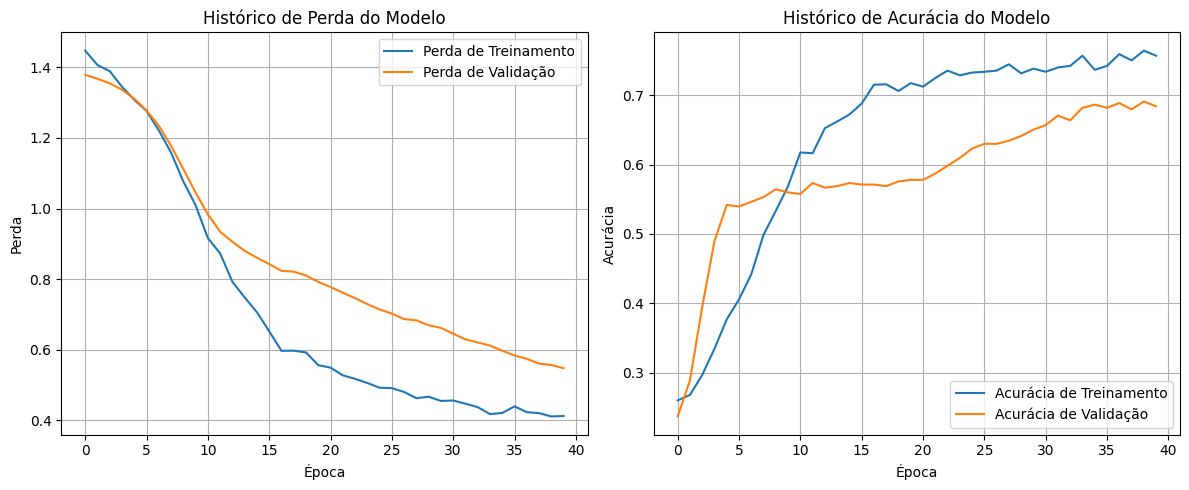

#########################################################################
Matriz de confusão
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 412ms/step


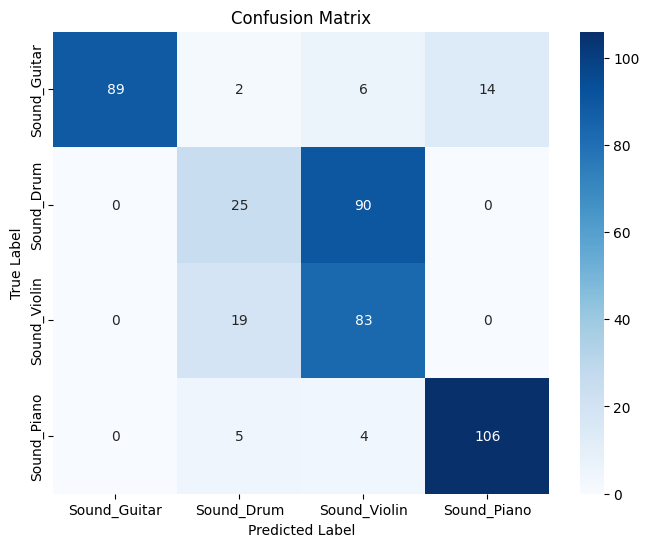

#########################################################################
Sumário do modelo


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 32)  │    122,912 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 32)  │    122,912 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 64)  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │                   │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 7, 7, 64)  │          0 │ concatenate[0][0] │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │     66,560 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,578,766 (28.91 MB)

 Trainable params: 2,175,620 (8.30 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 4,351,242 (16.60 MB)

In [ ]:
import matplotlib.pyplot as plt

print("#########################################################################")
print("Gráfica")
# Plotar a perda (loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda do Modelo')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

# Plotar a acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("#########################################################################")
print("Matriz de confusão")
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the test set
test_predictions_raw = model.predict(X_test)
test_predictions_classes = np.argmax(test_predictions_raw, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_predictions_classes, labels=range(len(CLASSES)))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("#########################################################################")
print("Sumário do modelo")
model.summary()



In [ ]:
def select_file():# Filter list to include only files
  # Uses test submission files
  dir_test = os.path.join(path, "Test_submission", "Test_submission")
  metdata_test_file=os.path.join(path, "Metadata_Test.csv")
  CLASSES=['Sound_Guitar', 'Sound_Drum', 'Sound_Violin', 'Sound_Piano']

  # Load metadata and correct common typos
  df = pd.read_csv(metdata_test_file)
  df['Class'] = df['Class'].replace({'Sound_Guiatr': 'Sound_Guitar'}) # Correct the typo here

  # Select random file
  files = [f for f in os.listdir(dir_test) if os.path.isfile(os.path.join(dir_test, f))]
  if files:
      random_file = random.choice(files)
      # Filter rows where a specific column matches a regex pattern
      matched_rows = df[df['FileName'].str.contains(random_file, na=False, regex=True)]
      random_file = os.path.join(dir_test, random_file)
  else:
      print("No files found in directory.")
      return None, None # Return None if no files are found

  if not os.path.isfile(random_file):
      print(f"Arquivo não encontrado: {random_file}")
      os.sys.exit(1)
  return random_file, matched_rows

In [ ]:
import pandas as pd

all_results = [] # Lista para armazenar os resultados de cada iteração

for i in range(10): # Loop 10 vezes
  print(f"\n--- Iteração {i+1}/10 ---")
  random_file, matched_rows = select_file() # Chamar a função para selecionar um novo arquivo e metadados
  print(f"Processando o arquivo de áudio: {os.path.basename(random_file)}")

  try:
      # `audio_to_mfcc` já converte para o tamanho e 3 canais
      spectrogram_image = audio_to_mfcc(audio_path=random_file,class_label=matched_rows['Class'].iloc[0])
      # Adiciona a dimensão do batch para o modelo
      input_spectrogram = np.expand_dims(spectrogram_image, axis=0)

      # 2. Make a prediction using the trained model
      predictions = model.predict(input_spectrogram)
      predicted_class_index = np.argmax(predictions)
      predicted_class_label = CLASSES[predicted_class_index]

      # 3. Get the true class label from matched_rows
      if not matched_rows.empty and 'Class' in matched_rows.columns:
          true_class_label = matched_rows['Class'].iloc[0]
      else:
          true_class_label = "Unknown (metadata not found)"
          print("Warning: Could not find true class label for the selected file.")

      # 4. Compare prediction with true class
      is_correct = (predicted_class_label == true_class_label)
      result = "Correct" if is_correct else "Incorrect"

      # 5. Store results in a DataFrame (for this iteration)
      iteration_results_df = pd.DataFrame({
          'File Name': [os.path.basename(random_file)],
          'True Class': [true_class_label],
          'Predicted Class': [predicted_class_label],
          'Prediction Result': [result]
      })
      all_results.append(iteration_results_df)

      # Print immediate feedback for each iteration
      if not is_correct:
          print(f"Oh não! A predição para '{os.path.basename(random_file)}' está INCORRETA.")
          print(f"O modelo previu '{predicted_class_label}' mas a classe verdadeira é '{true_class_label}'.")
      else:
          print(f"Excelente! A predição para '{os.path.basename(random_file)}' está CORRETA.")

  except Exception as e:
      print(f"Erro ao processar e predizer o arquivo {os.path.basename(random_file)}: {e}")

# Concatenar todos os resultados em um único DataFrame no final
if all_results:
    final_results_df = pd.concat(all_results, ignore_index=True)
    print("\n--- Resultados Finais de Todas as Predições ---")
    display(final_results_df)
else:
    print("Nenhuma predição foi realizada com sucesso.")

print("#########################################################################")
correct_predictions = final_results_df[final_results_df['Prediction Result'] == 'Correct'].shape[0]
total_predictions = final_results_df.shape[0]

if total_predictions > 0:
    accuracy = correct_predictions / total_predictions
    print(f"Acurácia do modelo no conjunto de teste: {accuracy:.2%}")
else:
    print("Não há predições para calcular a acurácia.")


--- Iteração 1/10 ---
Processando o arquivo de áudio: Sad-Violin-Fast-E-www.fesliyanstudios.com.wav
Erro ao processar e predizer o arquivo Sad-Violin-Fast-E-www.fesliyanstudios.com.wav: audio_to_mfcc() missing 1 required positional argument: 'class_label'

--- Iteração 2/10 ---
Processando o arquivo de áudio: yuwu-quiz-113046.wav
Erro ao processar e predizer o arquivo yuwu-quiz-113046.wav: audio_to_mfcc() missing 1 required positional argument: 'class_label'

--- Iteração 3/10 ---
Processando o arquivo de áudio: guitar-solo-5999.wav
Erro ao processar e predizer o arquivo guitar-solo-5999.wav: audio_to_mfcc() missing 1 required positional argument: 'class_label'

--- Iteração 4/10 ---
Processando o arquivo de áudio: Va-ord-F4-ff-2c.wav
Erro ao processar e predizer o arquivo Va-ord-F4-ff-2c.wav: audio_to_mfcc() missing 1 required positional argument: 'class_label'

--- Iteração 5/10 ---
Processando o arquivo de áudio: Va-ord-F4-ff-2c.wav
Erro ao processar e predizer o arquivo Va-ord-F4-